Train R2 Score: 0.8479
Test R2 Score: 0.8542


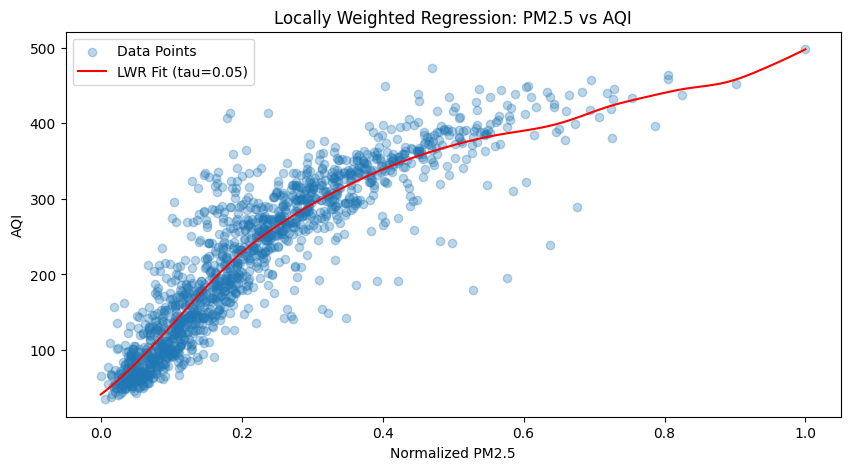

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load and prepare data
df = pd.read_csv('LWR.csv')
X = df['PM2.5'].values.reshape(-1, 1)
y = df['AQI'].values

# Normalize features to [0, 1] for easier tau selection
X_norm = (X - X.min()) / (X.max() - X.min())
X_bias = np.c_[np.ones(X_norm.shape[0]), X_norm] # Add bias term

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bias, y, test_size=0.2, random_state=42)

def lwr_predict(X_train, y_train, x_query, tau=0.05):
    """Predicts y for a single query point using LWR."""
    m = X_train.shape[0]
    W = np.eye(m)
    for i in range(m):
        diff = X_train[i, 1] - x_query[1]
        W[i, i] = np.exp(-(diff**2) / (2 * tau**2))
    
    # Solve (X^T * W * X) theta = X^T * W * y
    theta = np.linalg.pinv(X_train.T @ W @ X_train) @ (X_train.T @ W @ y_train)
    return x_query @ theta

# Compute Predictions
tau = 0.05
y_pred_test = np.array([lwr_predict(X_train, y_train, x, tau) for x in X_test])
y_pred_train = np.array([lwr_predict(X_train, y_train, x, tau) for x in X_train])

# Accuracy Metrics
print(f"Train R2 Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R2 Score: {r2_score(y_test, y_pred_test):.4f}")

# Plotting the Fit
X_plot = np.linspace(0, 1, 100)
X_plot_bias = np.c_[np.ones(100), X_plot]
y_plot = np.array([lwr_predict(X_train, y_train, xp, tau) for xp in X_plot_bias])

plt.figure(figsize=(10, 5))
plt.scatter(X_norm, y, alpha=0.3, label='Data Points')
plt.plot(X_plot, y_plot, color='red', label=f'LWR Fit (tau={tau})')
plt.title('Locally Weighted Regression: PM2.5 vs AQI')
plt.xlabel('Normalized PM2.5')
plt.ylabel('AQI')
plt.legend()
plt.show()

Training Accuracy: 88.37%
Testing Accuracy: 72.97%


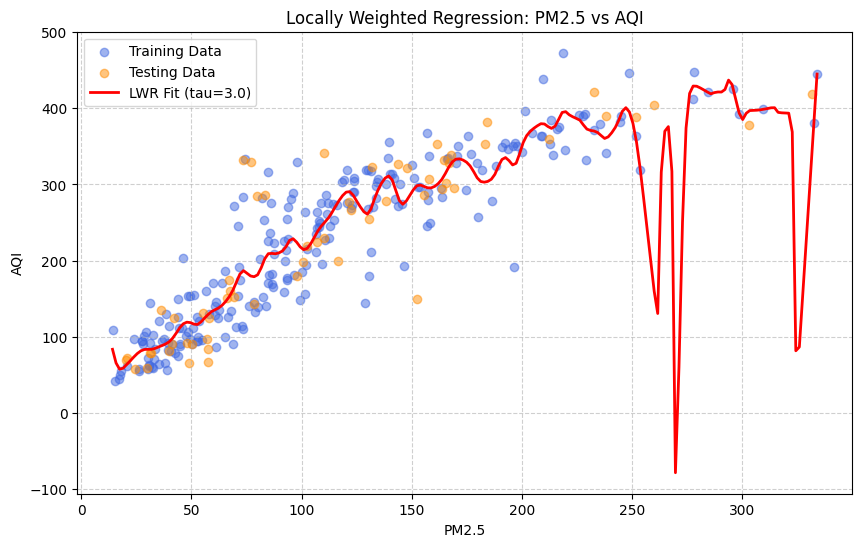

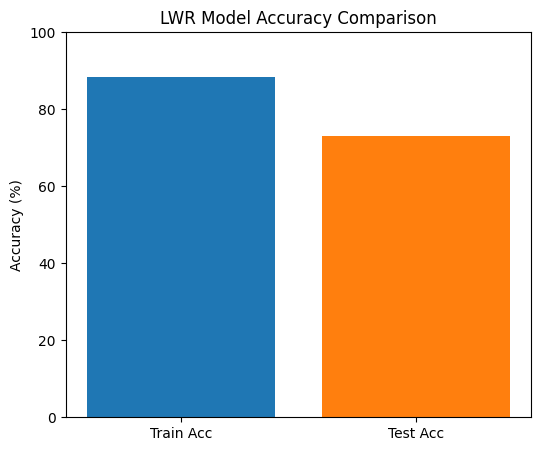

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load the dataset
df = pd.read_csv('LWR.csv')

# 2. Select appropriate features and target
# Choosing PM2.5 and AQI for visualization purposes
subset_df = df.sample(n=300, random_state=42).sort_values(by='PM2.5')
X = subset_df[['PM2.5']].values
y = subset_df['AQI'].values

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the Kernel and LWR Functions
def gaussian_kernel(x0, X, tau):
    """Calculates weights for each training point relative to query point x0."""
    return np.exp(np.sum((X - x0)**2, axis=1) / (-2 * (tau**2)))

def local_weighted_regression(x0, X_train, y_train, tau):
    """Predicts the value for a single query point x0."""
    # Add bias term (column of 1s)
    x0_bias = np.array([1, x0[0]])
    X_train_bias = np.column_stack((np.ones(X_train.shape[0]), X_train))

    # Compute diagonal weight matrix W
    weights = gaussian_kernel(x0_bias, X_train_bias, tau)
    W = np.diag(weights)

    # Solve Normal Equation: beta = (X.T * W * X)^-1 * X.T * W * y
    # Adding small identity matrix for numerical stability
    xtwx = X_train_bias.T @ W @ X_train_bias
    try:
        beta = np.linalg.solve(xtwx, X_train_bias.T @ W @ y_train)
    except np.linalg.LinAlgError:
        beta = np.linalg.pinv(xtwx) @ (X_train_with_bias.T @ W @ y_train)

    return x0_bias @ beta

def get_predictions(X_query, X_train, y_train, tau):
    return np.array([local_weighted_regression(x, X_train, y_train, tau) for x in X_query])

# 4. Execute Predictions
tau_value = 3.0
y_train_pred = get_predictions(X_train, X_train, y_train, tau_value)
y_test_pred = get_predictions(X_test, X_train, y_train, tau_value)

# 5. Calculate Accuracy (R^2 Score)
train_acc = r2_score(y_train, y_train_pred) * 100
test_acc = r2_score(y_test, y_test_pred) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy: {test_acc:.2f}%")

# 6. Plotting Results
# Regression Curve
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='royalblue', label='Training Data', alpha=0.5)
plt.scatter(X_test, y_test, color='darkorange', label='Testing Data', alpha=0.5)

x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_range_pred = get_predictions(x_range, X_train, y_train, tau_value)
plt.plot(x_range, y_range_pred, color='red', label=f'LWR Fit (tau={tau_value})', linewidth=2)

plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.title('Locally Weighted Regression: PM2.5 vs AQI')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('lwr_regression.png')

# Performance Bar Chart
plt.figure(figsize=(6, 5))
plt.bar(['Train Acc', 'Test Acc'], [train_acc, test_acc], color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Accuracy (%)')
plt.title('LWR Model Accuracy Comparison')
plt.ylim(0, 100)
plt.savefig('accuracy_chart.png')
